# Time Series Mean Reversion

Here real data is analyzed for mean reversion by using a stationary ARIMA model and a Fractional Brownian motion model

In [171]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from datetime import datetime
from pandas import DataFrame, read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison, stack, periodogram, variance_agg, PlotType, mean_reversion_halflife
from lib.data import arima, adf, stats, fbm, HypothesisTestType, ou

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Stationary Autoregressive Process 

Stationary autoregressive time series are mean reverting. Here the USD.CAD exchange rate is tested for stationarity using the ADF test. It is seen that the time series is not stationary but it is close to stationary. Using the periodogram method it is found that $H=0.48$ and variance aggregation gives $H=0.45$. The Variance ratio test 

In [172]:
file_path = os.path.abspath('../../../data/algorithmic_trading/CAD=X.csv')
usd_cad = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
usd_cad.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2003-09-17,1.3667,1.3704,1.3636,1.3667,1.3667,0.0
2003-09-18,1.3660,1.3685,1.3597,1.3615,1.3615,0.0
2003-09-19,1.3620,1.3630,1.3457,1.3472,1.3472,0.0
2003-09-22,1.3413,1.3553,1.3365,1.3542,1.3542,0.0
2003-09-23,1.3549,1.3577,1.3458,1.3551,1.3551,0.0


In [173]:
date = usd_cad.index.to_numpy()
exch = usd_cad['Close'].to_numpy()

In [174]:
lower =  date > numpy.datetime64('2007-07-22')
date = date[lower]
exch = exch[lower]
upper = date < numpy.datetime64('2012-03-28')
date = date[upper]
exch = exch[upper]
exch_mean = numpy.full(len(date), numpy.mean(exch))

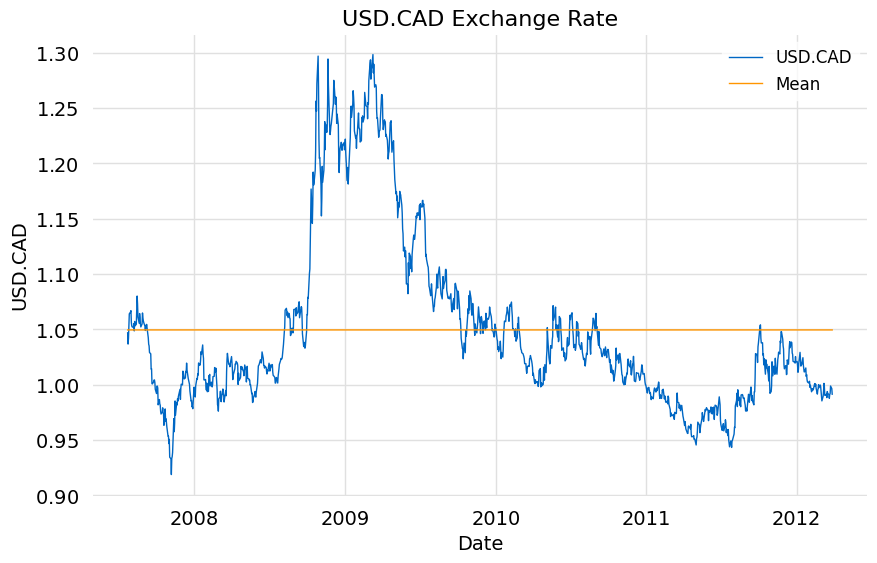

In [175]:
title = 'USD.CAD Exchange Rate'
comparison([exch, exch_mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)

In [176]:
result, _ = adf.compute_adf_offset_test(exch, max_lag=12)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │   -1.60531  │
├────────────────┼─────────────┤
│ pvalue         │    0.480923 │
├────────────────┼─────────────┤
│ Lags           │    9        │
├────────────────┼─────────────┤
│ Number Obs     │ 1205        │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -3.43579 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -2.86394 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -2.56805 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


## Fractional Brownian Motion Process

If a fractional brownian motion model is used on the same time series the variance ratio test can be used to test for anticorrelation and the Hurst exponent is estimated using the both the periodogram and variance aggregation methods. The Hurst parameter $H$ is evaluated using both the periodogram method and variance aggregation method. The results are $H=0.48$ and $H=0.45$ respectively. The variance ratio test for anitcorrelation passes. This is consistent with the stationarity test where ADF barley failed.

In [177]:
t, diff_exch = stats.compute_diff(numpy.arange(len(exch)), exch)

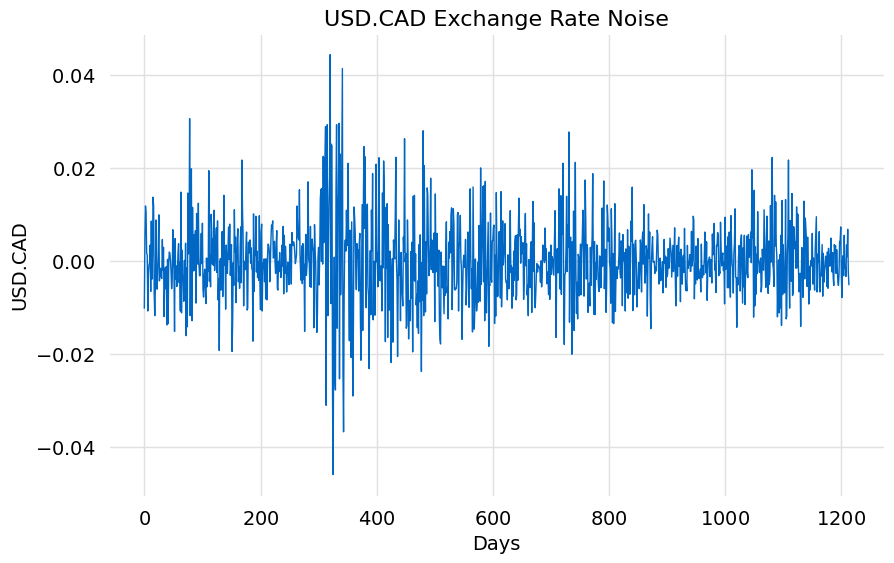

In [178]:
title = 'USD.CAD Exchange Rate Noise'
curve(diff_exch, t, title=title, xlabel="Days", ylabel="USD.CAD", lw=1)

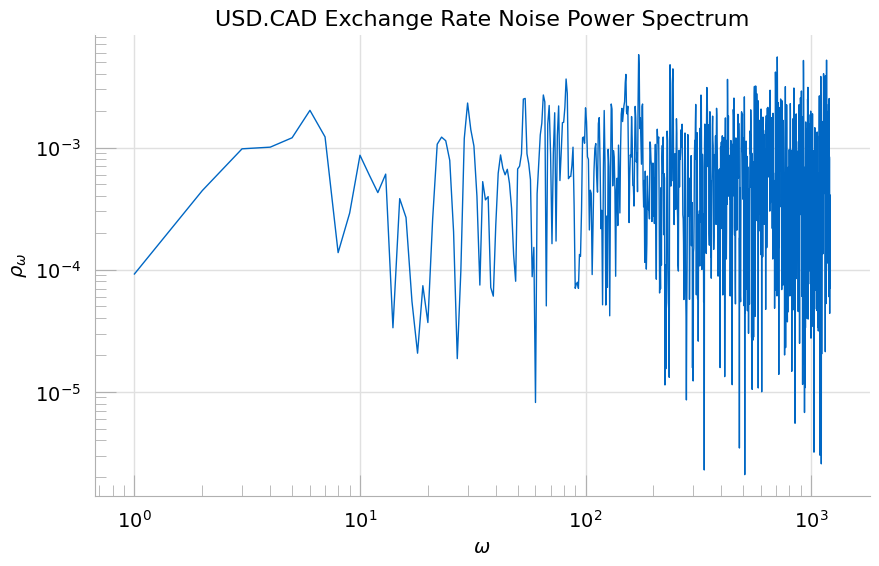

In [179]:
freq, ps = stats.compute_pspec(t, diff_exch)

title = 'USD.CAD Exchange Rate Noise Power Spectrum'
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [180]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.06179
Date:                Sat, 16 Dec 2023   Prob (F-statistic):              0.804
Time:                        16:21:22   Log-Likelihood:                -998.80
No. Observations:                1213   AIC:                             2002.
Df Residuals:                    1211   BIC:                             2012.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3100      0.099    -33.350      0.000      -3.505      -3.115
x1            -0.0092      0.037     -0.249      0.804      -0.082       0.063
==============================================================================
Omnibus:                      171.664   Durbin-Watson:                   1.214
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              263.951
Skew:                          -0.970   Prob(JB):                     4.83e-58
Kurtosis:                       4.208   Cond. No.                         19.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [181]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -3.3100215251305647,
      "err": 0.0992511901111557,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "c8fbe202-b93e-4a6c-8203-d5b4d83145ac",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.00918689706057186,
         "err": 0.03695686881021254,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "c8fbe202-b93e-4a6c-8203-d5b4d83145ac",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 5.1024770521324037e-05,
   "param_transforms": [
      {
         "param": {
            "est": 0.504593448530286,
            "err": 0.01847843440510627,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "o

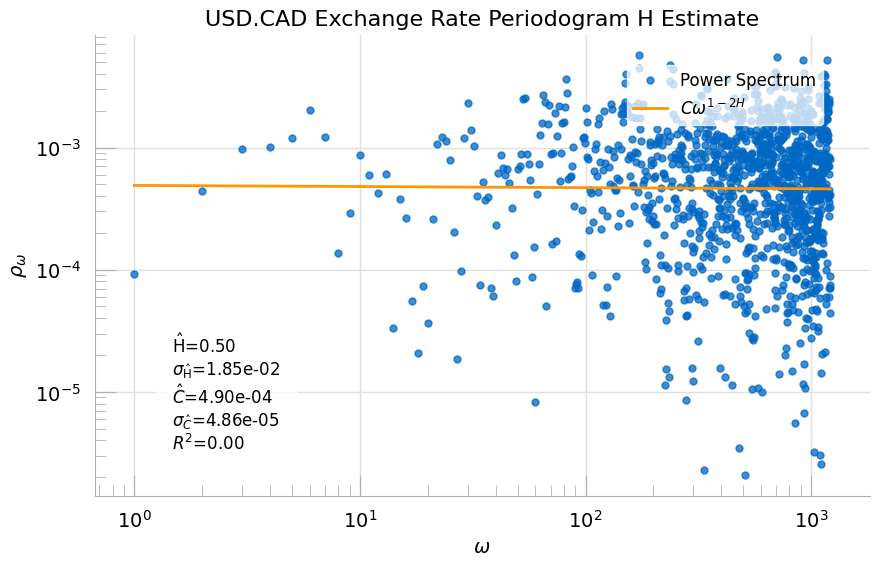

In [182]:
periodogram(ps, result_model, freq, title=f"USD.CAD Exchange Rate Periodogram H Estimate")

In [183]:
nagg = 100
m_vals, agg_var = stats.compute_agg_var(diff_exch, m_max=nagg, npts=nagg)

In [184]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     1901.
Date:                Sat, 16 Dec 2023   Prob (F-statistic):           5.54e-66
Time:                        16:21:23   Log-Likelihood:                 90.280
No. Observations:                 100   AIC:                            -176.6
Df Residuals:                      98   BIC:                            -171.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.0626      0.040   -100.872      0.000      -4.143      -3.983
x1            -1.0775      0.025    -43.604      0.000      -1.127      -1.028
==============================================================================
Omnibus:                        0.002   Durbin-Watson:                   1.788
Prob(Omnibus):                  0.999   Jarque-Bera (JB):                0.097
Skew:                           0.002   Prob(JB):                        0.953
Kurtosis:                       2.847   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [185]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.0625838464539,
      "err": 0.040274635556716204,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "0e27acb2-dddf-4b6c-a8b7-c787f5401704",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.0774992054506876,
         "err": 0.024711268691794956,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "0e27acb2-dddf-4b6c-a8b7-c787f5401704",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9509821123092042,
   "param_transforms": [
      {
         "param": {
            "est": 0.4612503972746562,
            "err": 0.012355634345897478,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "orde

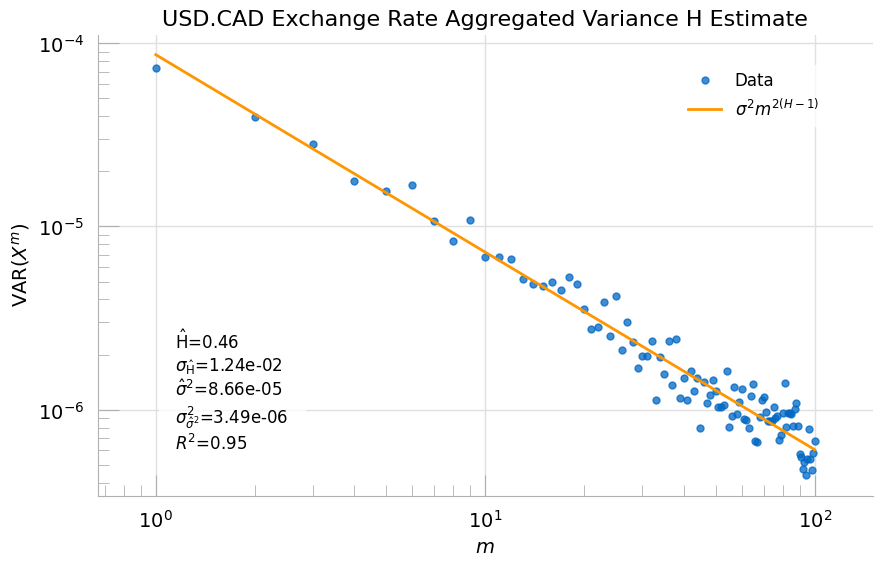

In [186]:
variance_agg(agg_var, result_model, m_vals, title=f"USD.CAD Exchange Rate Aggregated Variance H Estimate")

In [187]:
result, result_model = fbm.compute_vr_test(exch, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.415 │    0.661 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.713 │    0.762 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.081 │    0.532 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.581 │    0.281 │ Passed   │
├─────┼────────┼──────────┼───────

In [188]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "5b7f5627-0c9f-413a-8f13-a91b6988bd18",
                "label": "$Z(s)$",
                "value": 0.4150846799152601
            },
            "pval": {
                "test_id": "5b7f5627-0c9f-413a-8f13-a91b6988bd18",
                "label": "$p-value$",
                "value": 0.6609600429403613
            },
            "params": [
                {
                    "test_id": "5b7f5627-0c9f-413a-8f13-a91b6988bd18",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "5b7f5627-0c9f-413a-8f13-a91b6988bd18",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "5b7f5627-0c9f-413a-8f13-a91b6988bd18",
         

## Half-Life For Mean Reversion

The $\text{AR}(1)$ process with constant offset is defined by,

$
\begin{align}
X_t = \varphi X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t \sim \text{Normal}(0, 1)$. Subtracting $X_{t-1}$ from both sides gives,

$
\begin{align}
\Delta X_t = \left(\varphi - 1 \right) X_{t-1} \Delta t + \mu\Delta t + \sigma \sqrt{\Delta t} \varepsilon_t
\end{align}
\tag{2}
$

This can be reparameterized to,

$
\begin{align}
\Delta X_t = \lambda \left(\frac{\mu}{\lambda} + X_{t-1}\right)\Delta t + \sigma\sqrt{\Delta t} \varepsilon_t
\end{align}
\tag{3}
$

where $\lambda = \varphi - 1$.

The continuous differential form of this equation is the Ornstein-Uhlenbeck SDE,

$
\begin{align}
dX_t = \lambda \left(\frac{\mu}{\lambda} + X_t \right) dt + \sigma dB_t
\end{align}
\tag{4}
$

where $dB_t \sim \text{Normal}(0, dt)$. The Ornstein-Uhlenbeck SDE models a mean reverting random process and can be solved using the integration factor, $e^{-\lambda t}$

$
\begin{align}
X_t = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right) + \sigma \int_0^t e^{\lambda\left( t - s \right)} dB_s
\end{align}
\tag{5}
$

The mean value is given by,

$
\begin{align}
\text{E}\left[ X_t \right] = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right)
\end{align}
\tag{6}
$

For the limit $t \to \infty$ a finite mean value requires $\lambda < 0$,

$
\begin{align}
\lim_{t\to\infty}\text{E}\left[ X_t \right] = -\frac{\mu}{\lambda}
\end{align}
\tag{7}
$

The half life of mean decay is the time to reach $\frac{1}{2}$ the $t \to \infty$ value from the initial value. This defines the timescale of the Ornstein-Uhlenbeck process. If $t_H$ denotes the half life. It follows that $X_{t_H}$ is given by,

$
\begin{align}
X_{t_H} = X_0 - \frac{1}{2}\left(\frac{\mu}{\lambda} + X_0 \right)
\end{align}
\tag{8}
$

Using $Eq(7)$ and $Eq(8)$ and solving for $t_H$ gives,

$
\begin{align}
t_H = -\frac{\ln{2}}{\lambda}
\end{align}
\tag{9}
$

$\lambda$ can be evaluated by using regression on the equation,

$
\begin{align}
\Delta X_t = \lambda X_{t-1}\Delta t + \mu\Delta t + \sigma \sqrt{\Delta t}\varepsilon_t
\end{align}
\tag{10}
$



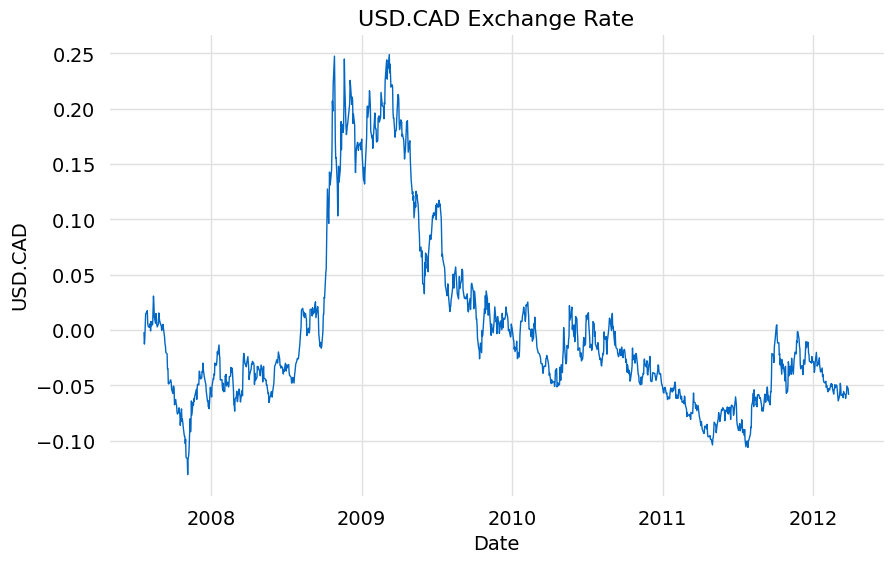

In [189]:
title = 'USD.CAD Exchange Rate'
xt = exch - exch_mean
curve(xt, date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)

In [190]:
result, result_model = ou.compute_mean_half_life_estimate(xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.256
Date:                Sat, 16 Dec 2023   Prob (F-statistic):             0.0714
Time:                        16:21:23   Log-Likelihood:                 4057.3
No. Observations:                1214   AIC:                            -8111.
Df Residuals:                    1212   BIC:                            -8100.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.542e-05      0.000     -0.185      0.853      -0.001       0.000
x1            -0.0056      0.003     -1.804      0.071      -0.012       0.000
==============================================================================
Omnibus:                      113.415   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.965
Skew:                           0.381   Prob(JB):                     5.83e-95
Kurtosis:                       5.828   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [191]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.541725118564352e-05,
      "err": 0.00024578554230089087,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "07fac76e-3610-4d2c-af74-8027aa04edff",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.005568763382202106,
         "err": 0.0030862402003987216,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "07fac76e-3610-4d2c-af74-8027aa04edff",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.0026791089715498817,
   "param_transforms": [
      {
         "param": {
            "est": 124.47057506075036,
            "err": 68.98229753251394,
            "est_label": "$t_{1/2}$",
            "err_label": "$\\sigma_{t_H}$",
            "row": 0,
            "column": 0,
            "order": 1

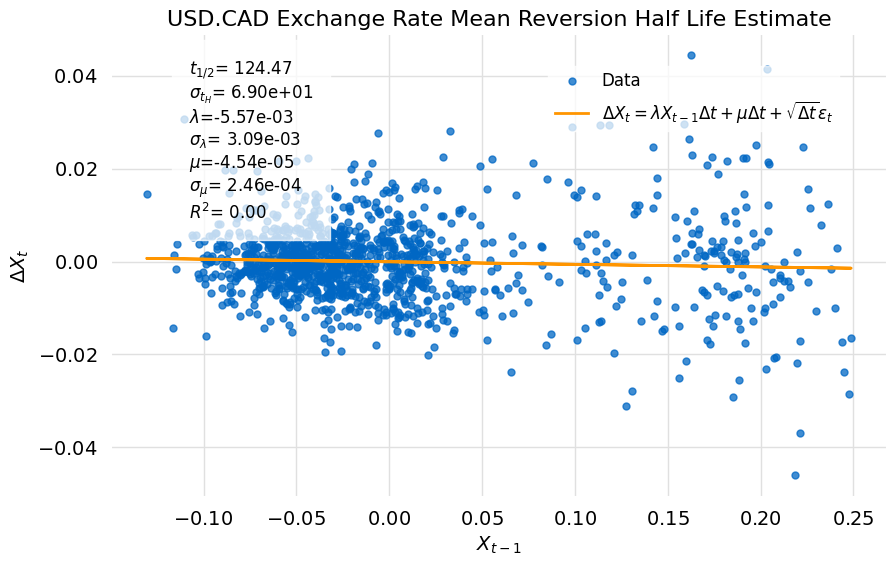

In [192]:
title = f"USD.CAD Exchange Rate Mean Reversion Half Life Estimate"
mean_reversion_halflife(xt, result_model, title=title, result_loc='upper right')

## Linear Trading Strategy

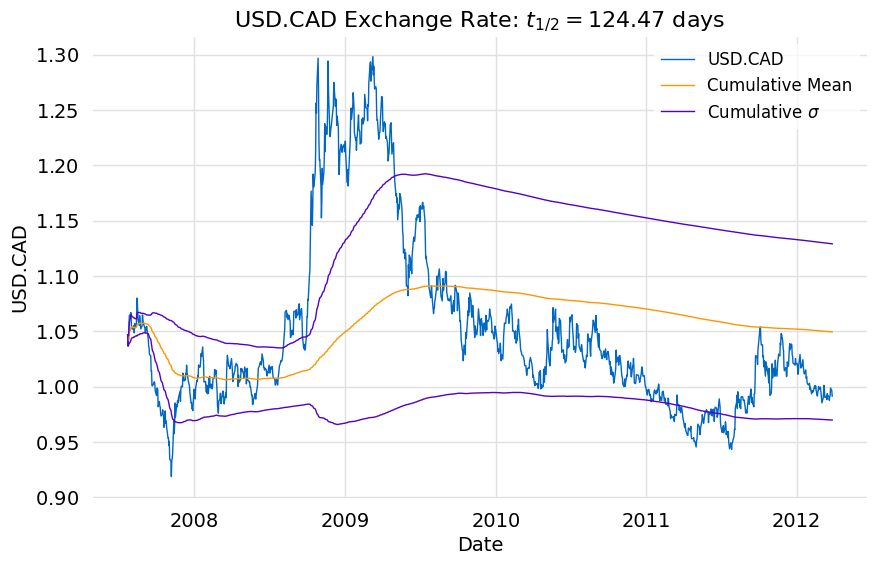

In [193]:
mean_reversion_half_life = result_model.param_transforms[0].param.est
title = f"USD.CAD Exchange Rate: $t_{{1/2}} = {mean_reversion_half_life:.2f}$ days"
_, cmean = stats.compute_cumu_mean(date, exch)
_, csd = stats.compute_cumu_sd(date, exch)
labels = ['USD.CAD', 'Cumulative Mean', r"Cumulative $\sigma$"]
colors = ['#0067C4', '#FF9500', '#5600C9', '#5600C9']
comparison([exch, cmean, cmean + csd, cmean - csd], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=labels, colors=colors, lw=1)

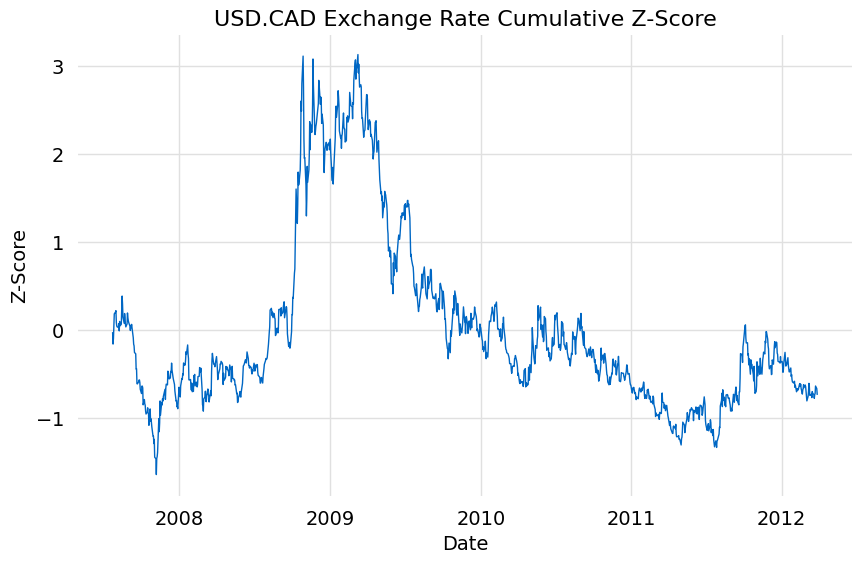

In [194]:
czdate, cz_score = stats.compute_cumu_zscore(date, exch)
title = 'USD.CAD Exchange Rate Cumulative Z-Score'
curve(cz_score, czdate, title=title, xlabel="Date", ylabel="Z-Score", lw=1)